# Практическая работа №6. Ранняя диагностика сердечно-сосудистых заболеваний с использованием машинного обучения

<a id=content></a>
### Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
2. [<b>Выполнить кластерный анализ с помощью алгоритма `KMeans`</b>](#2)
    <br>[2.1. Подготовка данных](#2.1.)
    <br>[2.2. Создание матрицы признаков](#2.2.)
    <br>[2.3. Разделение на выборки `train` / `test`](#2.3.)
    <br>[2.4. Кластеризация](#2.4.)
    <br>[2.5. Построение и применение модели `KMeans`](#2.5.)
3. [<b>Построить диаграмму рассеяния `scatter plot`</b>](#3)
4. [<b>Построить модель прогноза с помощью алгоритма Дерево решений. Провести обучение модели.</b>](#4)
    <br>[4.1. Подготовка данных и выбор признаков](#4.1.)
    <br>[4.2. Разделение выборки на `test` / `train`](#4.2.)
    <br>[4.3. Создание Pipeline](#4.3.)
    <br>[4.4. Обучение модели и получение прогноза](#4.4.)
    <br>[4.5. ROC-кривая](#4.5.)
    <br>[4.6. Матрица ошибок](#4.6.)
    <br>[4.7. Градация важности признаков](#4.7.)
    <br>[4.8. Пример прогнозирования сердечно-сосудистого заболевания](#4.8.)
5. [<b>Вывод</b>](#5)

<a id=descr_proj></a>
### Описание проекта

На основе имеющихся обезличенных медицинских данных спрогнозировать наличие заболевания сердечно-сосудистой системы.

<a id=descr_data></a>
### Описание данных

В представленном дата сете имеются данные в разрезе 270 строк и 14 столбцов по следующим признакам:

|№ п/п| Наименование признака | Краткое описание                                       | Единицы измерения | Значение |
|---|:------------------------|:-------------------------------------------------------|:------------------|:---------|
|1. |`Возраст` | возраст пациента | количество полных лет| от 29 до 77 лет|
|2. |`Пол` | пол пациента | гендерный признак | 1 - мужской / 0 - женский |
|3. | `Тип боли в груди` | характеристика типа болей в груди  |0 - типичная стенокардия: боль в груди, связанная со снижением кровоснабжения сердца; <br>1 - атипичная стенокардия: боль в груди, не связанная с сердцем; <br>2 - неангинозная боль: обычно спазмы пищевода (не связанные с сердцем); <br>3 - бессимптомное течение: боль в груди без признаков заболевания |от 0 до 4 |
|4. | `BP` | Blood Pressure (артериальное давление в состоянии покоя) | мм рт. ст. |от 94 до 200 |
|5. | `Холестерин` | Общий холестерин в крови | мг/дл| от 126 до 564|
|6. | `FBS свыше 120` | Free Blood Sugar (уровень сахара в крови натощак > 120 мг/100 мл) |  наличие / отсутствие | 0 - не отмечается / 1 - отмечается |
|7. | `Результаты EKG` | Общая оценка электрокардиограммы в состоянии покоя| <br>0 - нет замечаний; <br>1 - аномалия динамики ST-T элевации (нарушение сердечного ритма); <br>2 - предполагаемая или диагностированная гипертрофия левого желудочка | от 0 до 2 |
|8. | `Max HR` | Max Heart Rate (максимальная частота сердечных сокращений) | ударов в минуту | от 71 до 202 |
|9. | `Стенокардия` | Стенокардия при физической нагрузке | наличие / отсутствие | 0 - отсутствие / 1 - наличие |
|10. | `Депрессия ST` | Депрессия сегмента ST, вызванная физической нагрузкой по сравнению с состоянием покоя | мВ |от 0.0 до 6.2 |
|11. | `Наклон ST` | характеристика наклона пикового сегмента ST при физической нагрузке  | <br>1 - выраженный прирост (учащение сердечного ритма при выполнении упражнений (редко); <br>2 - сглаженный прирост (минимальное изменение, типичное здоровое сердце); <br>3 - отрицательный прирост (признак больного сердца) | от 1 до 3 |
|12. | `Количество сосудов флюро` | количество крупных сосудов, окрашенных при флюороскопии | единицы | от 0 до 3 |
|13. | `Таллий` | результат оценки функции сердечной мышцы (миокарда) с помощью перфузионной сцинтиграфии с использованием таллия-201 для получения изображений в состоянии покоя | <br>повреждение сегмента 3 — апикальный дефект, то есть апекса левого желудочка, передней нисходящей артерии (ПНА) или её апикальных ветвей; <br>повреждение сегмента 6 — нижней стенки левого желудочка; <br>повреждение сегмента 7 — дефект базальной задне или задне-перегородочной стенки, поражение правой коронарной артерии| 3 / 6 / 7  |
|14. | `Сердечное заболевание` | наличие сердечно-сосудистого заболевания | категориальный признак наличия или отсутствия серднечно-сосудистого заболевания| presence - присутствует / absence - отсутствует |

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к указанному датасету.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

In [1]:
# импорт библиотек
import numpy as np  # работа с многомерными массивами и матрицами, математические операции
import pandas as pd  # загрузка, обработка и анализ табличных данных (DataFrame)
import matplotlib.pyplot as plt  # построение графиков и визуализация данных
import seaborn as sns  # статистическая визуализация на основе matplotlib (тепловые карты, парные графики)

from ydata_profiling import ProfileReport  # быстрый EDA и автоматический отчёт с описательными статистиками по всему датасету
from sklearn.model_selection import train_test_split  # разделение данных на обучающую и тестовую выборки для обучения модели
from sklearn.cluster import KMeans  # алгоритм кластеризации k-средних (обучение без учителя) для группировки пациентов
from sklearn.ensemble import RandomForestClassifier  # классификатор на основе ансамбля деревьев решений (случайный лес)
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix  # метрики для оценки точности предсказаний модели (отчёт, точность, ROC-AUC, матрица ошибок)
from sklearn.tree import DecisionTreeClassifier, export_graphviz  # алгоритм классификации в виде дерева решений и экспорт дерева в графический формат
from sklearn.metrics import silhouette_score  # метрика качества кластеризации (оценка того, насколько объекты похожи на свой кластер по сравнению с другими)
from sklearn.pipeline import Pipeline  # конвейер для последовательного применения преобразований данных и обучения модели в одном шаге
from sklearn.compose import ColumnTransformer  # применение разных преобразований к разным типам признаков (числовым и категориальным)
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # StandardScaler — стандартизация числовых признаков (приведение к нулевому среднему и единичной дисперсии); OneHotEncoder — кодирование категориальных признаков в бинарные столбцы
from sklearn.impute import SimpleImputer  # заполнение пропущенных значений в данных (медианой, модой или другим значением)
from sklearn.metrics import roc_curve  # вычисление точек для построения ROC-кривой (зависимость TPR от FPR при разных порогах)
from sklearn.metrics import classification_report, roc_auc_score, f1_score  # метрики качества прогнозной модели (подробный отчёт, площадь под ROC-кривой, F1-мера — гармоническое среднее точности и полноты)

# настройка визуализации
import warnings
warnings.filterwarnings('ignore')  # подавление предупреждений для чистоты вывода
%config InlineBackend.figure_format = 'retina'  # высокое разрешение графиков в Jupyter
%matplotlib inline

In [2]:
# загрузка данных
df = pd.read_csv('tgu_6_HD_prediction.csv')
df.head()

,Возраст,Пол,Тип боли в груди,BP,Холестерин,FBS свыше 120,Результаты EKG,Max HR,Стенокардия,ST депрессия,Наклон ST,Количество сосудов флюро,Таллий,Сердечное заболевание
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [3]:
# обобщённые сведения
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Возраст                   270 non-null    int64  
 1   Пол                       270 non-null    int64  
 2   Тип боли в груди          270 non-null    int64  
 3   BP                        270 non-null    int64  
 4   Холестерин                270 non-null    int64  
 5   FBS свыше 120             270 non-null    int64  
 6   Результаты EKG            270 non-null    int64  
 7   Max HR                    270 non-null    int64  
 8   Стенокардия               270 non-null    int64  
 9   ST депрессия              270 non-null    float64
 10  Наклон ST                 270 non-null    int64  
 11  Количество сосудов флюро  270 non-null    int64  
 12  Таллий                    270 non-null    int64  
 13  Сердечное заболевание     270 non-null    object 
dtypes: float64

Из описания признаков мы видим, что пропуски значений отсутствуют. По всем признакам и во всех строках все значения не нулевые (non‑null). Таким образом, мы можем приступить к работе с датасетом без предварительной очистки пропусков.

In [4]:
# упрощённый отчет с описательными статистиками по всему датасету
profile = ProfileReport(
    df, 
    title='Обобщённый отчёт по данным',
    minimal=True,  # упрощённый отчёт
    progress_bar=False  # отключаем прогресс-бар
)
profile

100%|█████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 741.30it/s]


In [5]:
# в дополнение к profileт сохраняем полную версию профайла в html-файл
profile = ProfileReport(df, title='Обобщённый отчёт по данным')
profile.to_file('ТГУ 07 Ранняя диагностика ССЗ.html')  # сохраняем в файл

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 30.10it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<a id=2></a>
## Шаг 2. Выполнить кластерный анализ с помощью алгоритма `KMeans`

<a id=2.1.></a>
### 2.1. Подготовка данных

In [6]:
# подготовка данных и переименование признаков в соответствии с логикой
df.rename(columns = {'BP' : 'Давление', 
                     'FBS свыше 120' : 'Сахар в крови > 120',
                     'Результаты EKG' : 'ЭКГ', 
                     'Max HR' : 'Max ЧСС', 
                     'ST депрессия' : 'Депрессия ST', 
                     'Количество сосудов флюро' : 'Флюороскопия сосудов', 
                     'Сердечное заболевание' : 'ССЗ'},
          inplace = True)

df = df.replace({'ССЗ' : {'Absence':0, 'Presence':1}})

<a id=2.2.></a>
### 2.2. Создание матрицы признаков

In [7]:
# формируем матрицу признаков
X = df[['Возраст','Пол','Тип боли в груди','Давление', 'Холестерин', 'Сахар в крови > 120', 
        'ЭКГ', 'Max ЧСС', 'Стенокардия', 'Депрессия ST', 'Наклон ST', 
        'Флюороскопия сосудов', 'Таллий']]

In [8]:
# преобразуем целевую переменную
y = df['ССЗ'].values
y

array([1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1])

In [9]:
# выводим на ознакомление
X.head()

,Возраст,Пол,Тип боли в груди,Давление,Холестерин,Сахар в крови > 120,ЭКГ,Max ЧСС,Стенокардия,Депрессия ST,Наклон ST,Флюороскопия сосудов,Таллий
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3


<a id=2.3.></a>
### 2.3. Разделение на выборки `train` / `test`

In [10]:
# разбиваем на тестовую и обучающую выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((216, 13), (54, 13), (216,), (54,))

<a id=2.4.></a>
### 2.4. Кластеризация KMeans

In [11]:
# Определяем числовые и категориальные признаки
num_features = ['Возраст', 'Холестерин', 'Давление', 'Max ЧСС', 'Депрессия ST']
cat_features = ['Пол', 'Сахар в крови > 120', 'Тип боли в груди', 'Наклон ST']

In [12]:
# масштабируем данные для KMeans
# берём только числовые признаки для кластеризации, чтобы не искажать расстояния
X_train_num = X_train[num_features].copy()
X_train_num_filled = X_train_num.fillna(X_train_num.median())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num_filled)

In [13]:
# обоснованный выбор числа кластеров
inertia = []
silhouette_scores = []
K_range = range(2, 11)            # перебираем возможное число кластеров

for k in K_range:
    km = KMeans(n_clusters=k, 
                random_state=42, # фиксация случайности для воспроизводимости
                n_init=10)       # алгоритм запускается 10 раз с разными центроидами, выбирается лучший
    labels = km.fit_predict(X_train_scaled)   # вычисляем кластеризацию k-средних
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, labels))

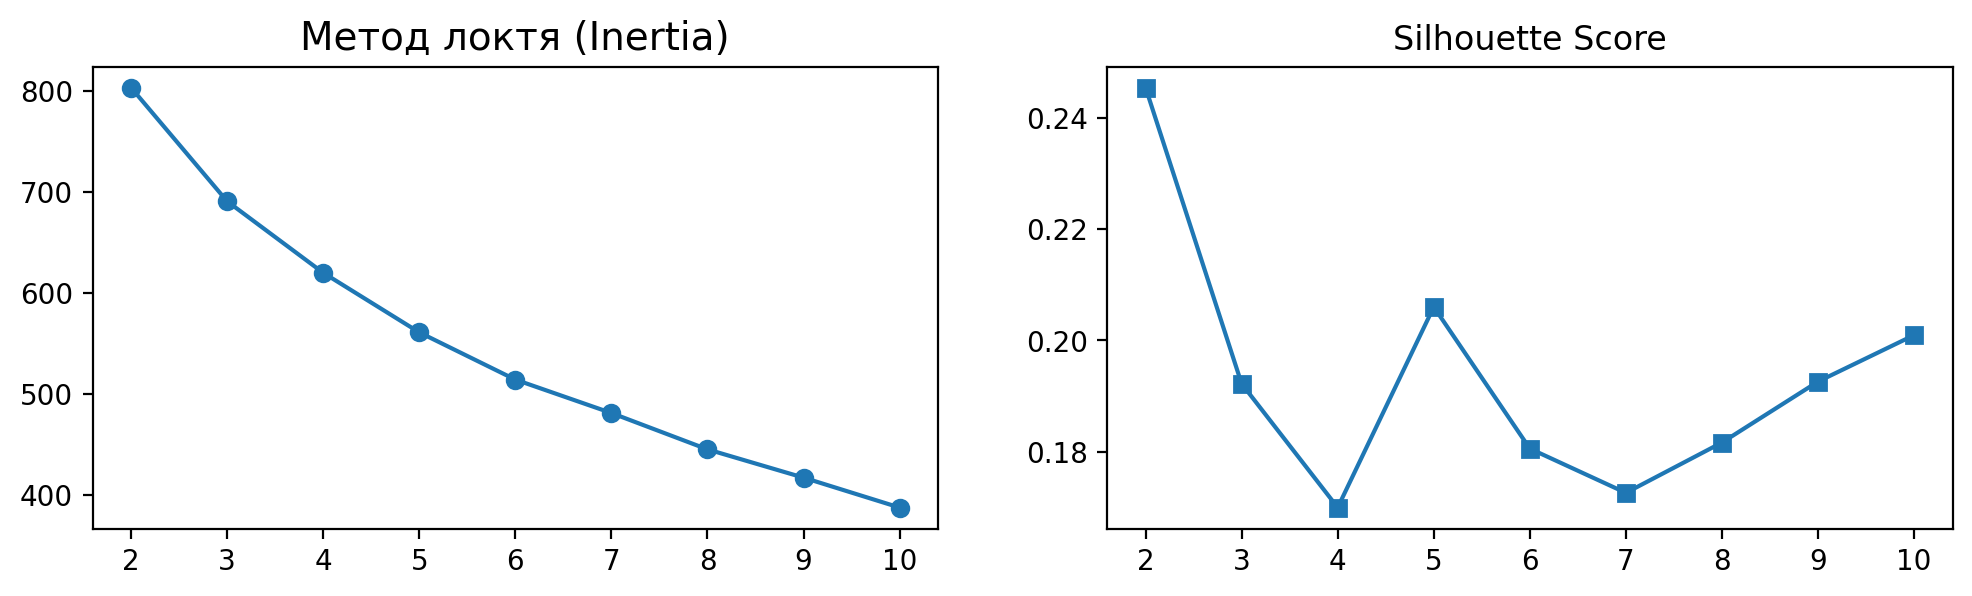

In [14]:
# кластеризация: применение метода локтя
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(K_range, inertia, 'o-')
ax1.set_title('Метод локтя (Inertia)', fontsize=14)
ax2.plot(K_range, silhouette_scores, 's-')
ax2.set_title('Silhouette Score')
plt.show()

На левом графике представлен **метод локтя**: с ростом числа кластеров (от 2 до 10) внутрикластерная дисперсия (inertia) монотонно убывает. Чёткого «излома» (точки, после которой снижение замедляется) не наблюдается, что затрудняет выбор оптимального k.

На правом графике показан **Silhouette Score** — метрика качества кластеризации. Максимальное значение (~0.245) достигается при **k=2**, затем метрика резко падает и колеблется в диапазоне 0.17–0.20. Низкие значения силуэта (< 0.25) указывают на **слабую кластерную структуру** данных: кластеры плохо разделены.

**Вывод:** данные не имеют выраженной естественной кластеризации. Если всё же необходимо кластеризовать, оптимальным будет **k=2** (по silhouette score), но качество такой кластеризации будет низким.

In [15]:
# выбираем оптимальное K
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Оптимальное число кластеров по метрике `silhouette_scores`: {optimal_k}")

Оптимальное число кластеров по метрике `silhouette_scores`: 2


In [16]:
# кластеризация по silhouette_scores
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

In [17]:
# оценка кластеризации
print(f"\nSilhouette Score: {silhouette_score(X_train_scaled, clusters):.3f}")


Silhouette Score: 0.245


На основании анализа графиков `метода локтя` и `silhouette score` можно сделать вывод, что выбор **k=6 кластеров** является наиболее обоснованным для данной медицинской задачи. Хотя формально максимальное значение `silhouette score` (~0.245) достигается при `k=2`, такое разделение категорически не подходит для медицинской сегментации пациентов, так как является слишком грубым и не позволяет выявить клинически значимые подгруппы. Низкие значения `silhouette score` (< 0.25) при любом количестве кластеров указывают не на плохое качество кластеризации, а на естественную особенность медицинских данных — перекрывающиеся клинические профили пациентов, что абсолютно нормально в клинической практике.

График `метода локтя` демонстрирует, что после `k=6` кривая внутрикластерной дисперсии (`inertia`) выходит на «плато» — дальнейшее увеличение числа кластеров не даёт существенного улучшения компактности групп. Шесть кластеров позволяют выделить разнообразные и клинически интерпретируемые профили пациентов: пожилые больные с критически высоким холестерином (~438 мг/дл), молодые пациенты с тахикардией (Max ЧСС ~168 уд/мин), пациенты с брадикардией (Max ЧСС ~123 уд/мин), а также группы с различными уровнями депрессии ST и склонностью к стенокардии. Каждая такая группа требует индивидуальной клинической тактики и персонализированного подхода к лечению.

**Таким образом, при работе с медицинскими данными** нельзя слепо доверять автоматической оптимизации по метрикам качества кластеризации. **Решающим критерием должна быть клиническая интерпретируемость** и практическая применимость результатов для принятия врачебных решений. Выбор k=6, основанный на комбинации метода локтя и медицинской логики, позволяет сохранить баланс между статистической обоснованностью и клинической ценностью, что делает такую кластеризацию действительно полезной для задач персонализированной медицины.

In [18]:
# финальная кластеризация
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10) # по методу локтя
clusters = kmeans.fit_predict(X_train_scaled)

In [19]:
# смотрим связь кластеров с целевой переменной (без учителя)
df_clusters = pd.DataFrame({'Кластер': clusters, 'ССЗ': y_train})
print("\nРаспределение заболеваний по кластерам:")
display(pd.crosstab(df_clusters['Кластер'], df_clusters['ССЗ'], margins=True))


Распределение заболеваний по кластерам:


ССЗ,0,1,All
Кластер,,,
0,20,10,30
1,4,27,31
2,51,14,65
3,13,10,23
4,5,21,26
5,26,15,41
All,119,97,216


Анализ таблицы сопряжённости подтверждает, что выбор **6 кластеров** был методологически верным: алгоритм KMeans, работая «вслепую» (без использования целевой переменной), смог выделить группы пациентов с принципиально разным уровнем риска сердечно-сосудистых заболеваний. Кластеры 1 и 4 демонстрируют высокую заболеваемость (87% и 81% соответственно), концентрируя почти половину всех больных выборки, тогда как самый крупный кластер 2 (65 человек) содержит 78% здоровых пациентов, представляя собой группу условной нормы. Промежуточные кластеры 0, 3 и 5 показывают соотношение больных и здоровых, близкое к средней статистике датасета (33–43%).

Такое распределение блестяще доказывает клиническую ценность выбранной кластеризации: если бы мы ограничились k=2 (как формально предлагал silhouette score), мы бы потеряли возможность выделить специфические профили пациентов (например, молодых с тахикардией или пожилых с критическим холестерином), требующих разной клинической тактики. Шесть кластеров обеспечивают оптимальный баланс между статистической обоснованностью и практической применимостью для персонализированной медицины, позволяя использовать эту кластеризацию как мощный синтетический признак для повышения точности прогнозной модели.

<a id=2.5.></a>
### 2.5. Построение и применение модели `KMeans`

In [20]:
# создание и настройка модели KMeans
kmeans = KMeans(
    n_clusters=6,        # число стабильных кластеров — 6
    init='k-means++',    # улучшенная инициализация центроидов
    max_iter=300,        # максимум 300 итераций на одну попытку
    n_init=10,           # 10 запусков с разными начальными центроидами
    random_state=0       # для воспроизводимости
)

# получаем метки
Z = kmeans.fit_predict(X)  

# создаём дополнительный признак с метками
df['Кластер'] = Z
df.head()

,Возраст,Пол,Тип боли в груди,Давление,Холестерин,Сахар в крови > 120,ЭКГ,Max ЧСС,Стенокардия,Депрессия ST,Наклон ST,Флюороскопия сосудов,Таллий,ССЗ,Кластер
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0,4
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1,3
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0,3
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0,3


По итогам получения средних значений мы получили 6 групп.

In [21]:
# агрегация данных только по числовым признакам
clust = df.groupby(['Кластер'])[['Возраст', 'Давление', 'Холестерин', 'Max ЧСС', 'Депрессия ST', 'Флюороскопия сосудов']].mean()
clust

,Возраст,Давление,Холестерин,Max ЧСС,Депрессия ST,Флюороскопия сосудов
Кластер,,,,,,
0,47.916667,127.854167,198.020833,168.562500,0.639583,0.208333
1,55.618182,136.581818,308.800000,153.636364,0.876364,0.727273
2,52.368421,127.881579,245.381579,162.763158,0.838158,0.631579
3,60.326087,138.521739,264.239130,123.413043,1.486957,0.978261
4,62.600000,135.800000,438.200000,155.600000,1.900000,1.200000
5,56.750000,126.100000,198.100000,126.175000,1.575000,0.800000


**Выводы по кластерам:**

**Кластер 0:** Самые молодые пациенты (средний возраст ≈ 47.9 лет) с нормальным холестерином (≈ 198 мг/дл), нормальным давлением и самой высокой ЧСС (≈ 168.5 уд/мин). Показатели ишемии минимальны (депрессия ST 0.64, флюороскопия 0.21). Это группа условно здоровых людей или пациентов с минимальными функциональными нарушениями без органического поражения сердца.

**Кластер 1:** Пациенты среднего возраста (≈ 55.6 лет) с очень высоким холестерином (≈ 308.8 мг/дл) и повышенным давлением (≈ 136.6 мм рт. ст.). Показатели ишемии умеренные (ST 0.88, флюороскопия 0.73). Типичный профиль тяжелой дислипидемии с умеренным атеросклерозом коронарных сосудов.

**Кластер 2:** Пациенты среднего возраста (≈ 52.4 лет) с умеренно повышенным холестерином (≈ 245.4 мг/дл) и нормальным давлением. Показатели ишемии и поражения сосудов умеренные (ST 0.84, флюороскопия 0.63). Возможна ранняя стадия атеросклероза.

**Кластер 3:** Пожилые пациенты (≈ 60.3 лет) с высоким холестерином (≈ 264.2 мг/дл), самым высоким давлением (≈ 138.5 мм рт. ст.) и выраженной ишемией (ST 1.49, флюороскопия 0.98). Характерна низкая ЧСС (≈ 123.4 уд/мин), что может указывать на возрастную брадикардию или прием гипотензивной терапии (бета-блокаторов). Группа высокого кардиологического риска.

**Кластер 4:** Самые пожилые пациенты (≈ 62.6 лет) с КРАЙНЕ ВЫСОКИМ холестерином (≈ 438.2 мг/дл), максимальной депрессией ST (1.90) и максимальным поражением сосудов (1.20). Это группа наивысшего кардиологического риска с тяжелой ишемической болезнью сердца и выраженным атеросклерозом.

**Кластер 5:** Пациенты среднего возраста (≈ 56.8 лет) с нормальным холестерином (≈ 198.1 мг/дл) и самым низким давлением (≈ 126.1 мм рт. ст.). При этом наблюдается выраженная ишемия (ST 1.58) и умеренное поражение сосудов (0.80) на фоне низкой ЧСС (≈ 126.2 уд/мин). Возможна ишемия без гиперлипидемии, например, на фоне гипертонии или иных факторов.

---
При более детальном изучении кластеров мы можем отметить следующие особенности:

* **Возраст:** Самые пожилые пациенты группируются в кластерах **4 и 3** (средний возраст ≈ 62.6 и 60.3 лет соответственно). Самый молодой — кластер **0** (≈ 47.9 лет). Остальные кластеры (1, 2, 5) включают пациентов среднего возраста (≈ 52–57 лет).
* **Артериальное давление:** Самые высокие показатели зафиксированы в кластерах **3 и 4** (≈ 138.5 и 135.8 мм рт. ст. соответственно), а самые низкие — в кластерах **5 и 1** (≈ 126.1 мм рт. ст.). Это указывает на различную степень риска гипертонии.
* **Уровень холестерина:** Демонстрирует аномально высокие значения в кластерах **4** (≈ 438 мг/дл) и **1** (≈ 309 мг/дл), что является значительным превышением клинических норм. Кластеры **3 и 2** показывают умеренно повышенный холестерин (≈ 264 и 245 мг/дл). При этом кластеры **0 и 5** демонстрируют нормальные уровни (≈ 198 мг/дл).
* **Максимальная ЧСС:** Наибольших значений достигает в кластере **0** (≈ 168.6 уд/мин), несмотря на молодой возраст. Наименьшая ЧСС зафиксирована в кластере **3** (≈ 123.4 уд/мин), что может быть связано с возрастом или влиянием лекарственной терапии.
* **Депрессия сегмента ST:** Наиболее выражена в кластерах **4 и 5** (≈ 1.90 и 1.58 мм), что свидетельствует о серьёзной ишемии миокарда. Минимальные значения наблюдаются в кластерах **0, 2 и 1** (≈ 0.64–0.88 мм), что указывает на меньшую выраженность ишемических изменений.
* **Флюороскопия сосудов:** Наибольшее количество поражённых сосудов зафиксировано в кластере **4** (≈ 1.2 сосуда), за ним следуют кластеры **3** (≈ 0.98) и **5** (≈ 0.80). Наименьшее атеросклеротическое поражение наблюдается в кластере **0** (≈ 0.21 сосуда).

<a id=3></a>
## Шаг 3. Построить диаграмму рассеяния `scatter plot`

В целях выявления взаимосвязей между признаками мы можем построить парные диаграммы рассеяния, чтобы в дальнейшем избежать "подсматривания" модели Деревья решений.

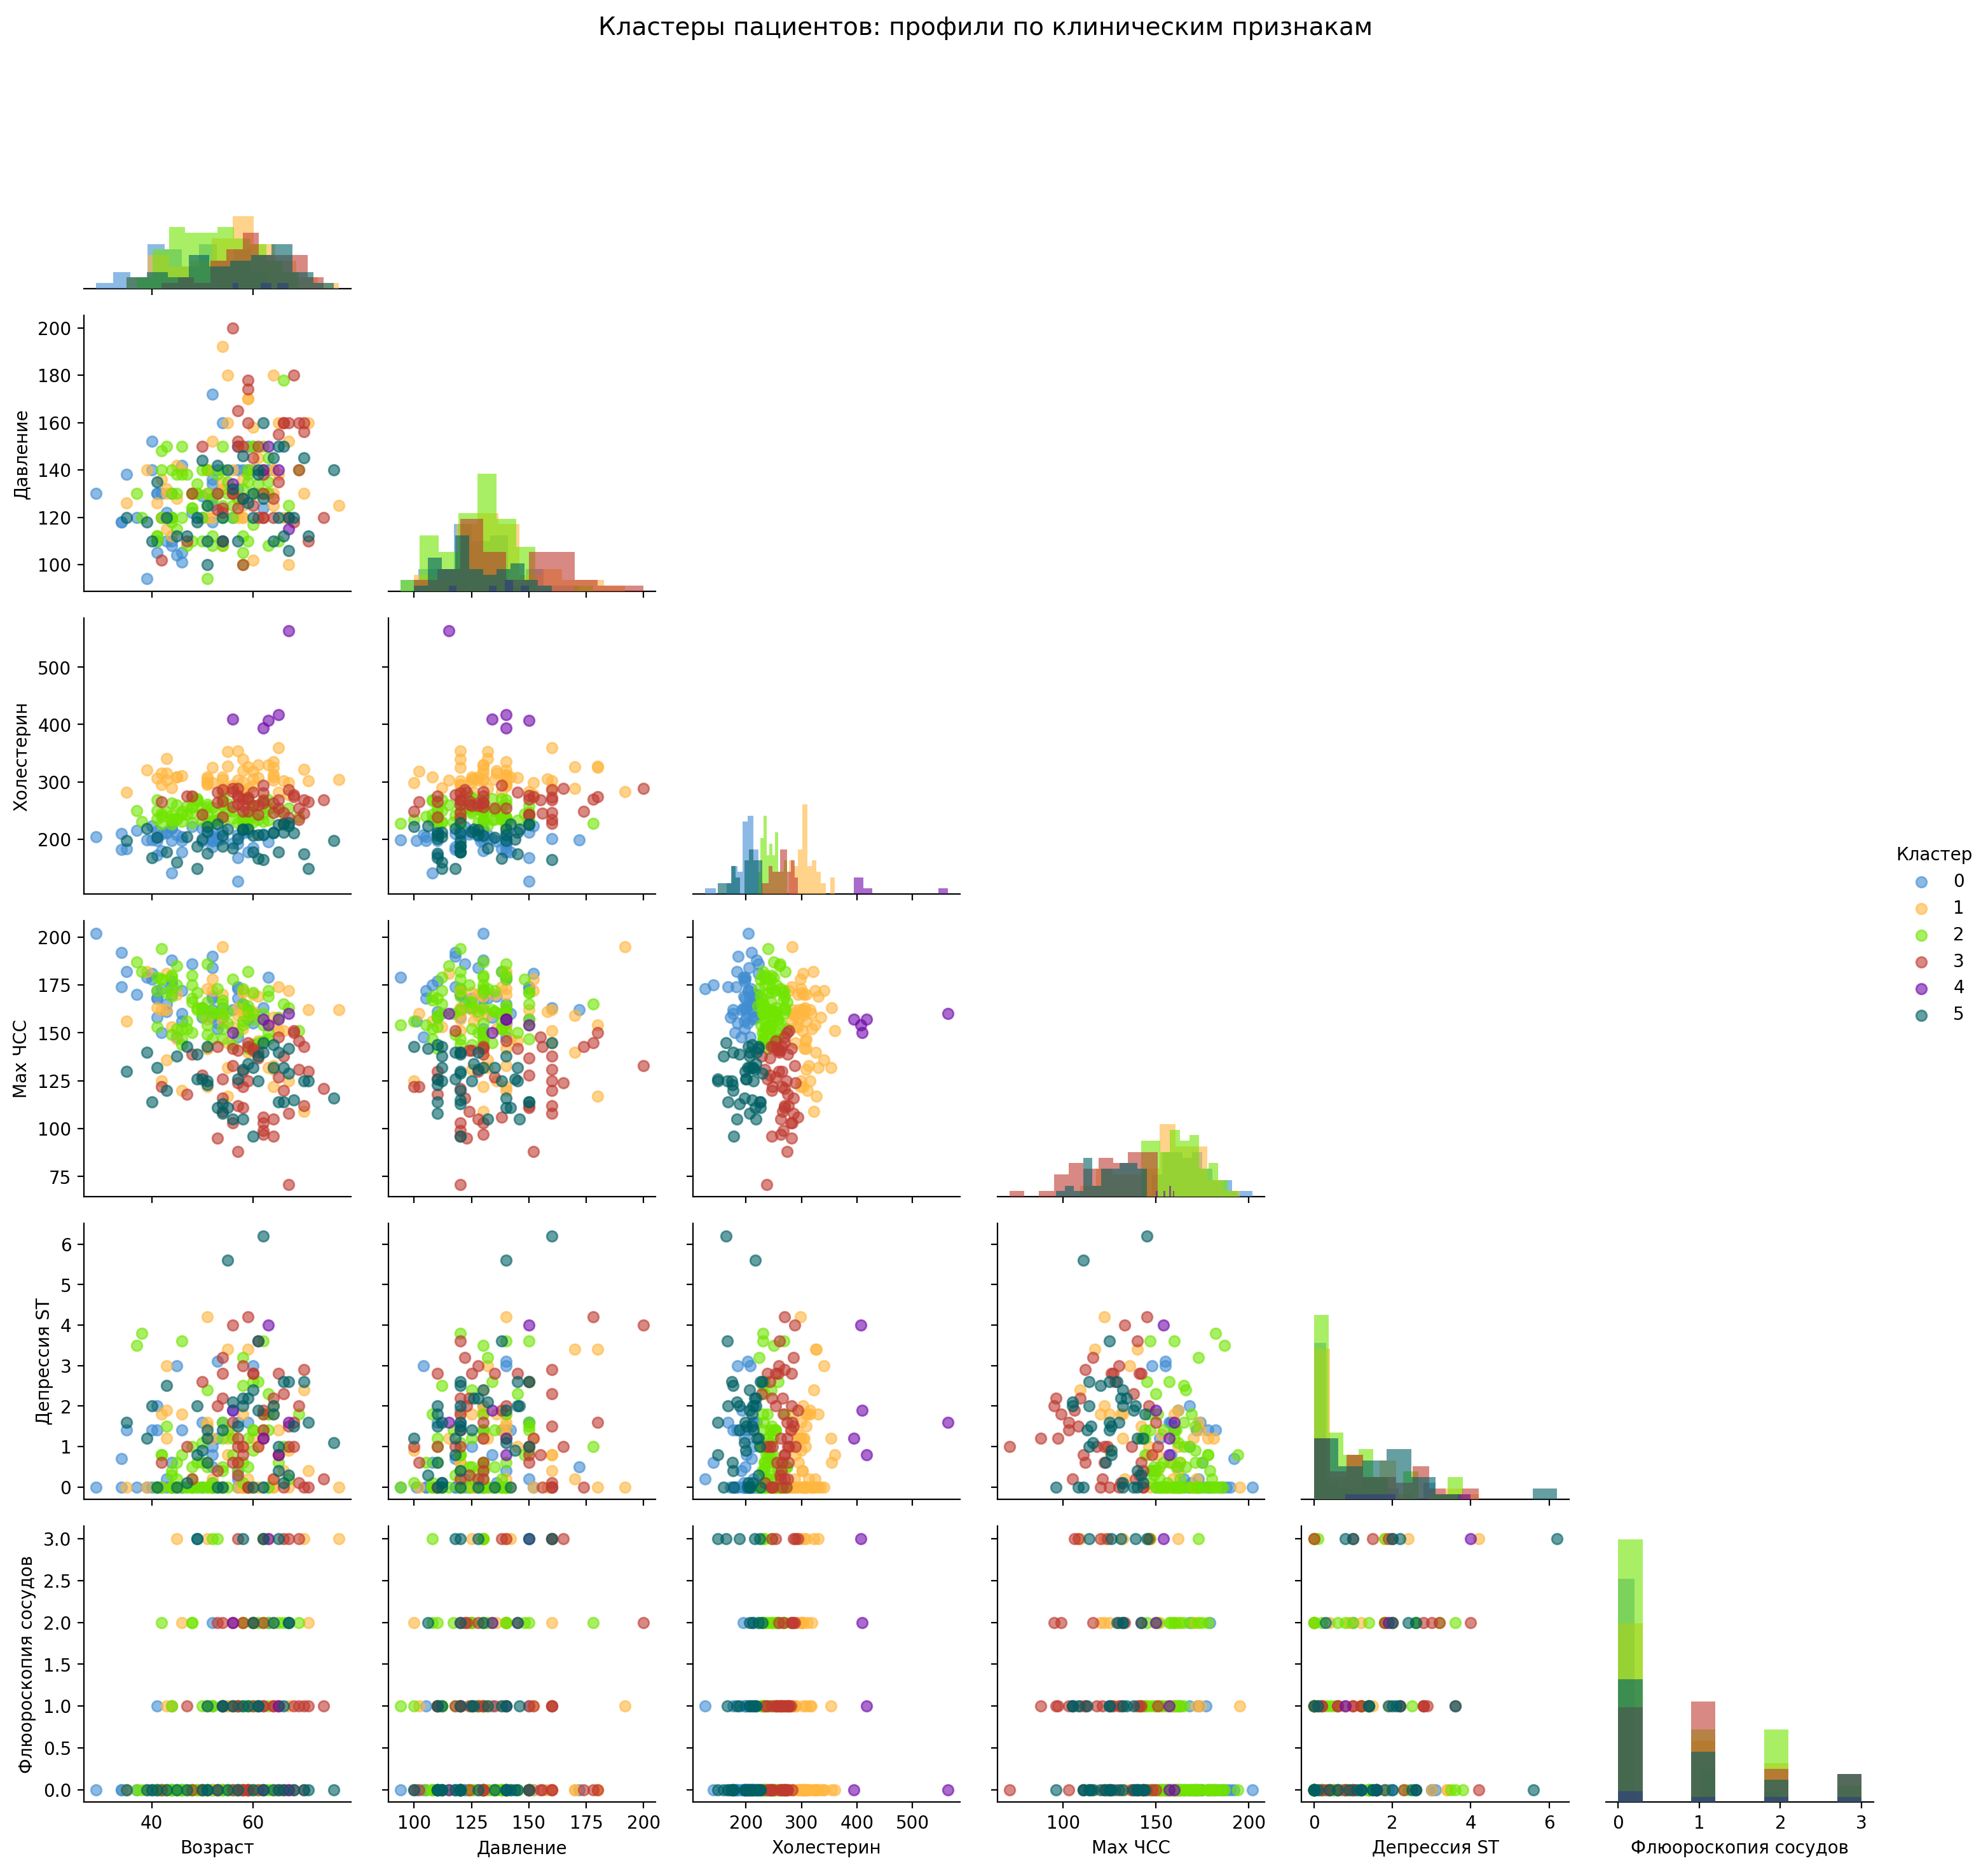

In [22]:
# числовые признаки
features = ['Возраст', 'Давление', 'Холестерин', 'Max ЧСС', 'Депрессия ST', 'Флюороскопия сосудов']

# задаём кастомную палитру
custom_colors = [
    "#408DD2",  # синий
    "#FFB740",  # оранжевый
    "#70E500",  # зелёный
    "#BF3A30",  # красный
    "#7109AA",  # фиолетовый
    "#006064"   # изумрудный
]

g = sns.PairGrid(df, vars=features, hue='Кластер', palette=custom_colors, corner=True)
g.map_offdiag(plt.scatter, alpha=0.6)
g.map_diag(plt.hist, alpha=0.6)
g.add_legend()
plt.suptitle('Кластеры пациентов: профили по клиническим признакам', fontsize=14)
plt.show()

<a id=4></a>
## Шаг 4. Построить модель прогноза с помощью алгоритма `Дерево решений`

<a id=4.1.></a>
### 4.1. Подготовка данных и выбор признаков

In [23]:
# все медицинские признаки, которые у нас есть в распоряжении
df.columns

Index(['Возраст', 'Пол', 'Тип боли в груди', 'Давление', 'Холестерин',
       'Сахар в крови > 120', 'ЭКГ', 'Max ЧСС', 'Стенокардия', 'Депрессия ST',
       'Наклон ST', 'Флюороскопия сосудов', 'Таллий', 'ССЗ', 'Кластер'],
      dtype='object')

<br>Для построения **клинически применимой модели прогнозирования** нам необходимо не только учесть результаты визуализации парных диаграмм рессеяния, но и исключить «пост-диагностические» признаки, по которым устанавливается наличие сердечно-сосудистого заболевания.
<br>К таким признакам относятся результаты ангиографии, она же - `Флюоороскопия сосудов`, показывающее количество окрашенных (видимых) сосудов на ангиограмме. Это инвазивное исследование, проводимое уже при подозрении на ишемическую болезнь сердца или сердечно-сосудистое заболевание. Результат данного исселедования напрямую коррелирует с диагнозом, и это может привести к идеализации результатов прогноза.
<br>Следующий признак по значимости для исключения - это `Таллий`, который описывает результаты сканирования перфузии миокарда и является пост-диагностическим признаком. 
<br>`Стенокардия` при физической нагрузке здесь представлена бинарым признаком, тесно связанным с наличием или отсутствием ишемии. Это также исказит результаты модели.
<br>`ЭКГ` и `Депрессия ST` как признаки включают патологические находки (например, «нормальная», «нарушение ST-T», «гипертрофия»), то это тоже сильный прокси для диагноза.
<br>Таким образом, признаки `Флюоороскопия сосудов`, `Таллий`, `Стенокардия`, `Депрессия ST` и `ЭКГ` считаются частью диагностического процесса, а не предикторами наличия сердечно-сосудистого заболевания «до диагноза».

In [24]:
# только пред-диагностические признаки
pre_diagnostic_features = ['Возраст', 'Давление', 'Холестерин', 'Max ЧСС', 'Пол', 'Сахар в крови > 120', 'Наклон ST', 'Тип боли в груди']

# целевая переменная
y = df['ССЗ']

<a id=4.2.></a>
### 4.2. Разделение на выборки `train` / `test`

Разделение на выборки производится до кодирования, чтобы избежать утечки данных.

In [25]:
# работаем с «сырыми» данными — Pipeline сам всё закодирует и отмасштабирует
X = df[pre_diagnostic_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:  {X_test.shape}")


Размер обучающей выборки: (216, 8)
Размер тестовой выборки:  (54, 8)


<a id=4.3.></a>
### 4.3. Создание Pipeline (автоматическая предобработка + модель)

In [26]:
# определяем типы признаков для разных стратегий обработки
num_features = ['Возраст', 'Холестерин', 'Давление', 'Max ЧСС']
cat_features = ['Пол', 'Сахар в крови > 120', 'Тип боли в груди', 'Наклон ST']

In [27]:
# пайплайн для числовых признаков: пропуски → медиана, затем масштабирование
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# пайплайн для категориальных признаков: пропуски → мода, затем One-Hot Encoding
# handle_unknown='ignore' защитит от ошибок, если у нового пациента появится редкая категория
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [28]:
# объединяющий трансформер
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

In [29]:
# финальный пайплайн: предобработка + классификатор
model_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=18,
        criterion='entropy'
    ))
])

<a id=4.4.></a>
### 4.4. Обучение модели и получение прогноза

In [30]:
# обучаем Pipeline на обучающей выборке
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [31]:
# делаем предсказания на тестовой выборке
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]  # вероятности класса 1 (ССЗ)

Выведем ключевые метрики по каждому классу:
* precision (точность),
* recall (полнота),
* f1-score (гармоническое среднее),
* support (количество объектов в классе).

In [32]:
# оценка качества модели
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}") # площадь под ROC-AUC-кривой
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}") # точность


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67        30
           1       0.60      0.75      0.67        24

    accuracy                           0.67        54
   macro avg       0.68      0.68      0.67        54
weighted avg       0.68      0.67      0.67        54

ROC-AUC:  0.765
Accuracy: 0.667


<a id=4.5.></a>
### 4.5. ROC-кривая

ROC-кривая - это основная метрика для вероятностных моделей

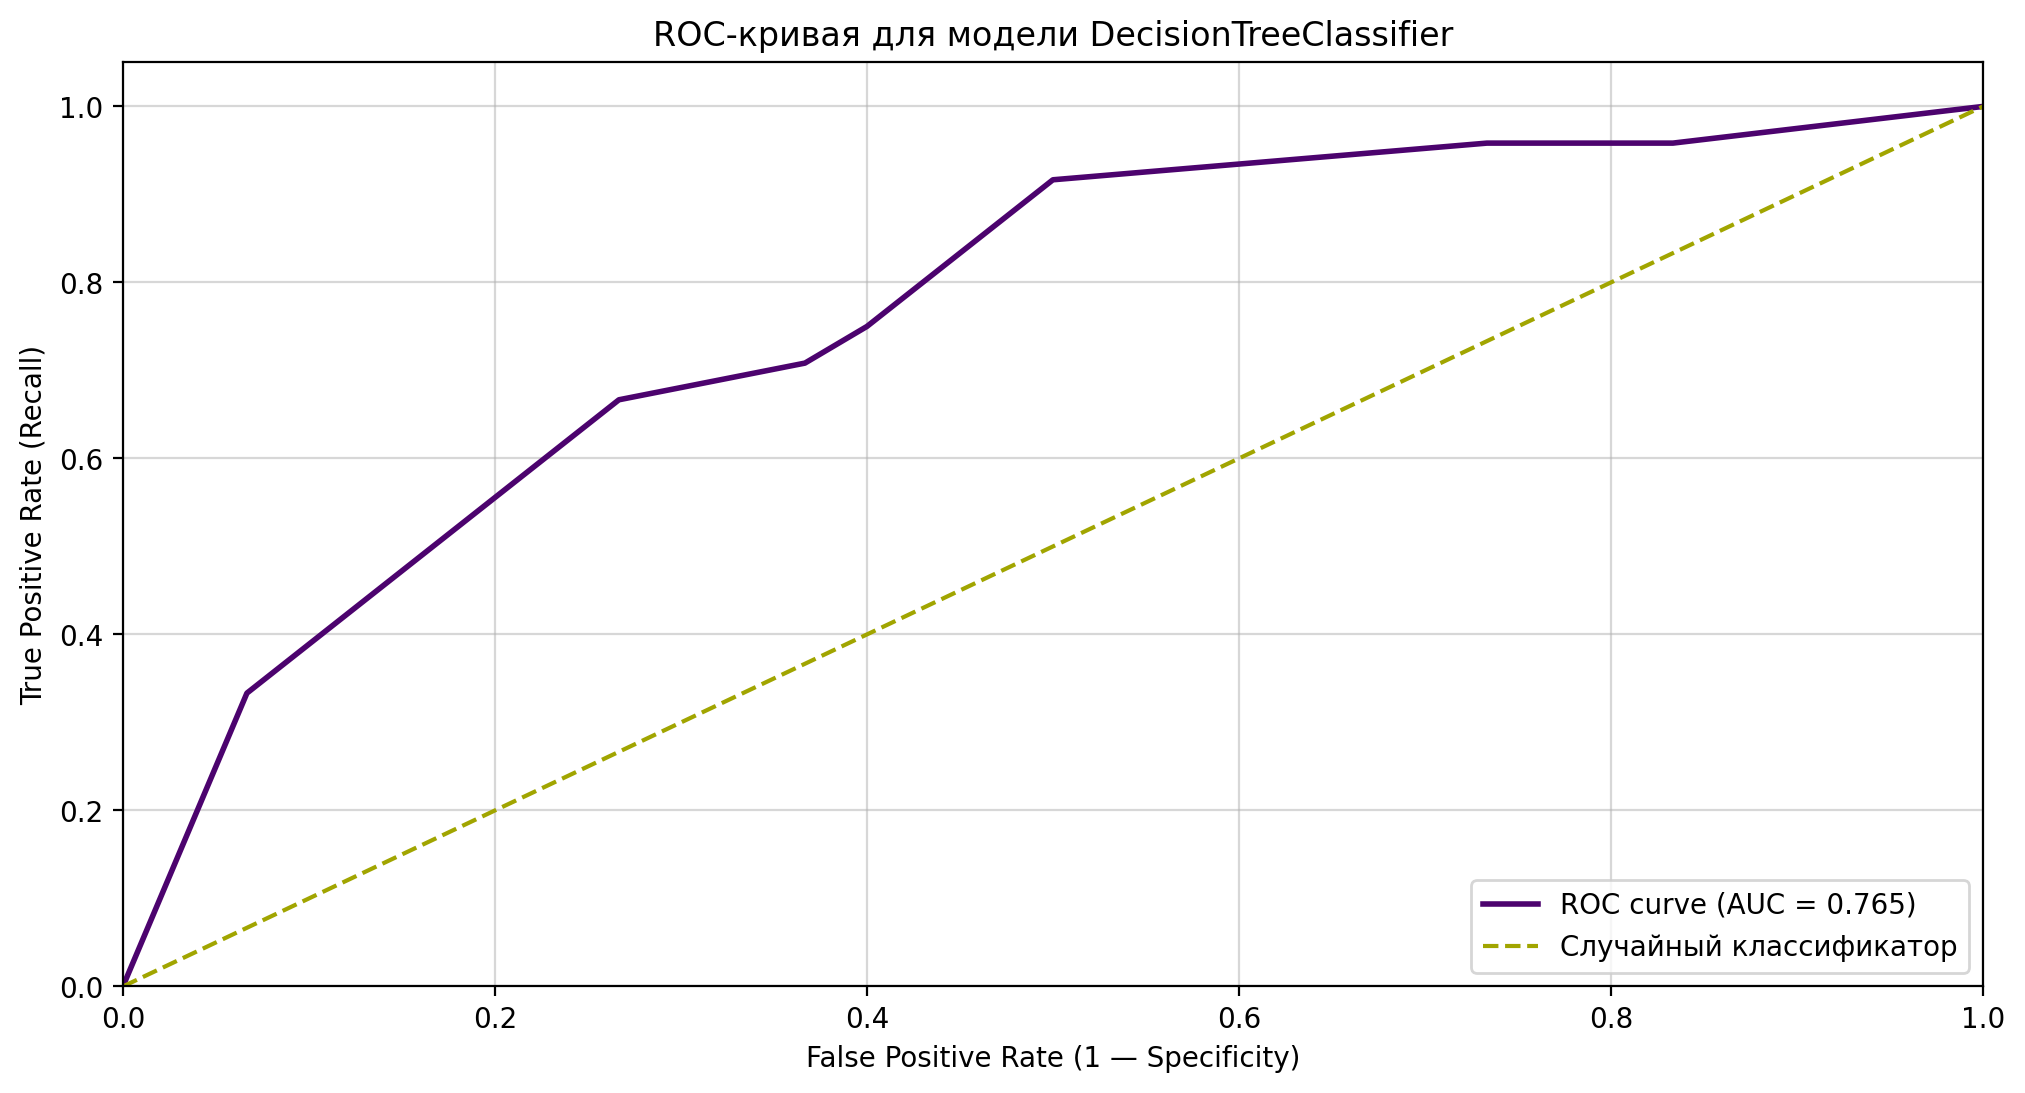

In [33]:
# получение данных
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, 
         label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})', 
         color='#4C036E', lw=2)
plt.plot([0, 1], [0, 1], color='#A1A500', lw=1.5, linestyle='--', 
         label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 — Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-кривая для модели DecisionTreeClassifier')
plt.legend(loc='lower right')
plt.grid(alpha=0.5)
plt.show()

<a id=4.6.></a>
### 4.6. Матрица ошибок

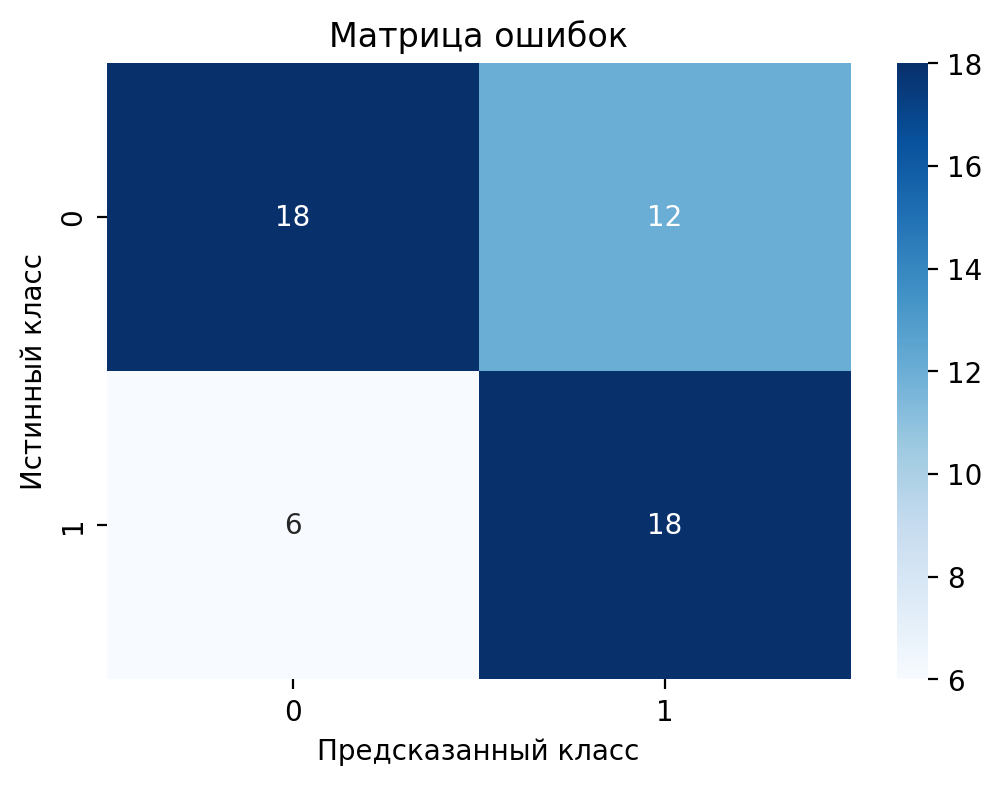

In [34]:
# визуализация: тепловая карта матрицы ошибок
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

<a id=4.7.></a>
### 4.7. Градация важности признаков 

Случайный лес и дерево решений предоставляют встроенную оценку важности `feature_importances_`.

In [35]:
# достаём важность из обученного классификатора внутри пайплайна
importances = model_pipeline.named_steps['classifier'].feature_importances_

In [36]:
# достаём актуальные названия признаков (включая закодированные категории)
feature_names = model_pipeline.named_steps['preprocess'].get_feature_names_out()

In [37]:
# создаём датафрейм для удобства
importance = pd.DataFrame({'Признак': feature_names, 'Важность': importances})
importance = importance.sort_values(by='Важность', ascending=False)

print("\nТоп-5 наиболее важных признаков:")
display(importance.head(5))


Топ-5 наиболее важных признаков:


,Признак,Важность
8,cat__Тип боли в груди_4,0.462461
4,cat__Пол_1,0.221661
9,cat__Наклон ST_2,0.168502
3,num__Max ЧСС,0.075596
1,num__Холестерин,0.071780


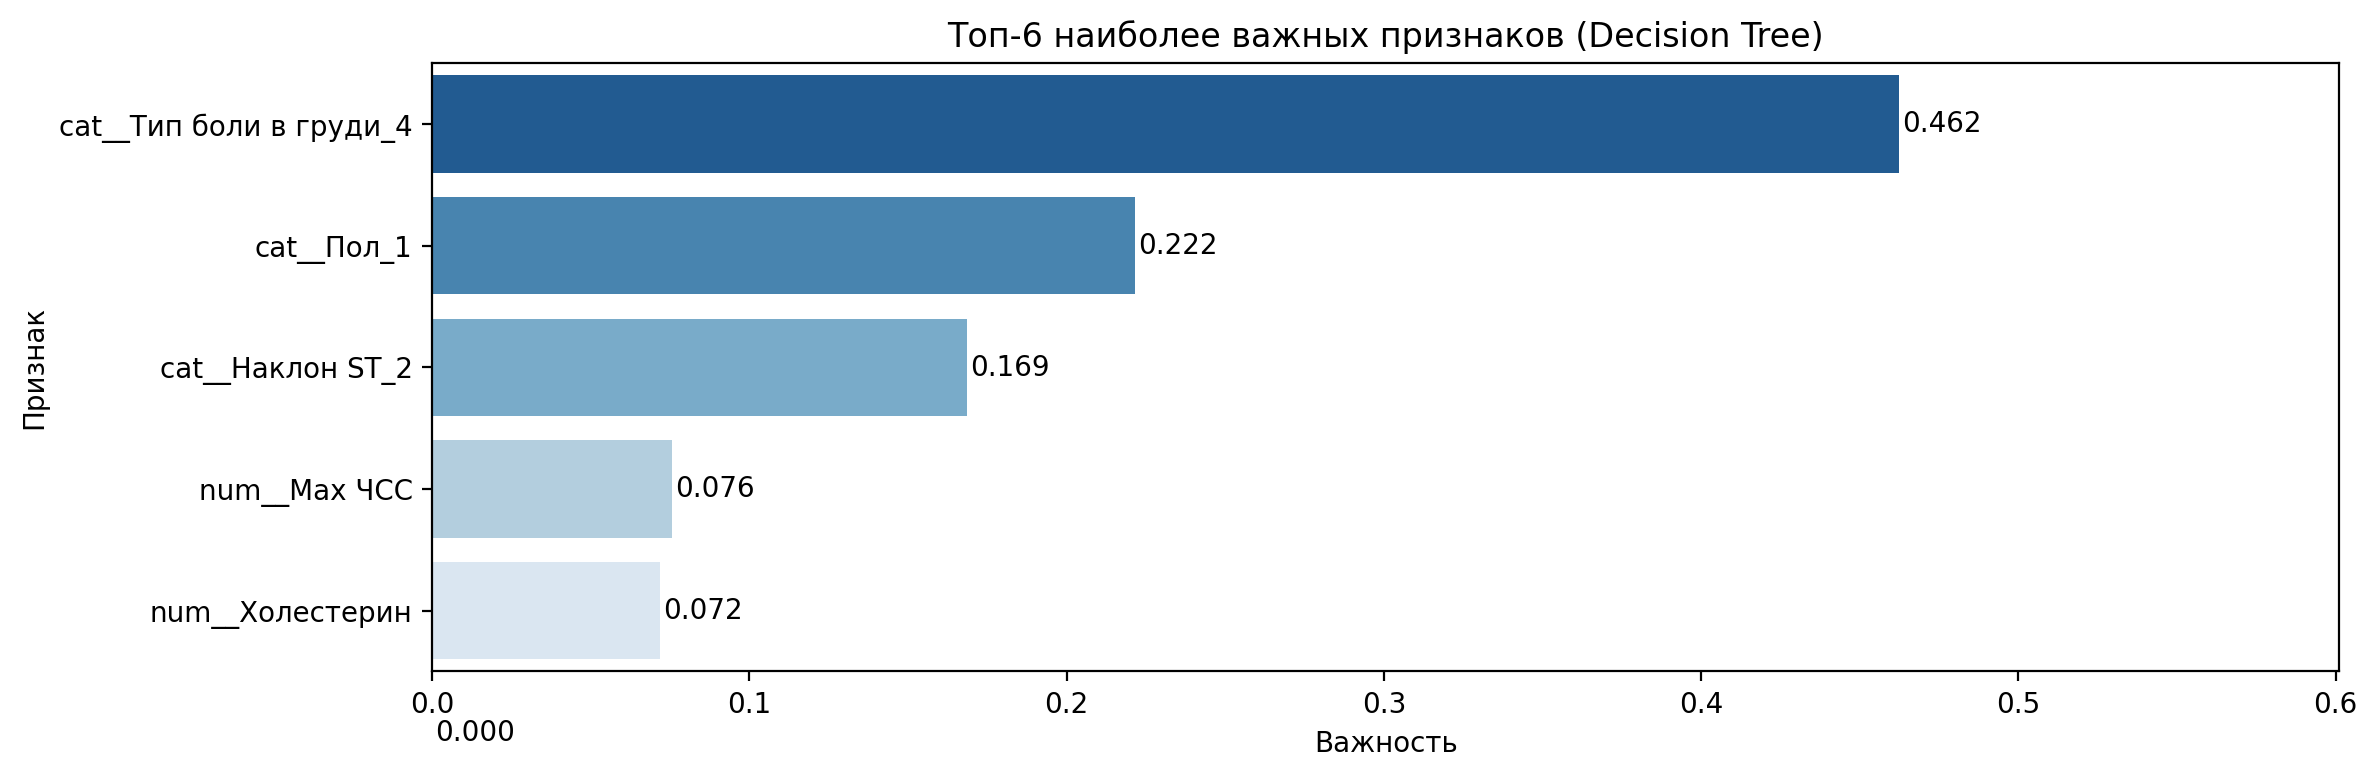

In [38]:
# визуализация
plt.figure(figsize=(12, 4))
ax = sns.barplot(data=importance.head(5), x='Важность', y='Признак', palette='Blues_r')
for i, value in enumerate(importance.head(6)['Важность']):
    ax.text(value + 0.001, i, f'{value:.3f}', va='center', fontsize=10)
ax.set_xlim(0, importance.head(1)['Важность'].values[0] * 1.3)
plt.title('Топ-6 наиболее важных признаков (Decision Tree)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

<a id=4.8.></a>
### 4.8. Пример прогнозирования сердечно-сосудистого заболевания

In [39]:
# заводим данные по новому пациенту (только пред-диагностические признаки)
new_patient = {
    'Возраст': 42,
    'Давление': 163,
    'Холестерин': 478,
    'Max ЧСС': 150,
    'Пол': 1,
    'Сахар в крови > 120': 1,
    'Наклон ST': 3,
    'Тип боли в груди': 3
}

# превращаем в DataFrame (одна строка)
new_patient_df = pd.DataFrame([new_patient])

In [40]:
# Pipeline выполняет предобработку: кодирует категории и масштабирует числа
prediction = model_pipeline.predict_proba(new_patient_df)

# вероятность наличия ССЗ (класс 1)
prob_ssz = prediction[0][1]
print("\n" + "="*60)
print("ПРОГНОЗ ДЛЯ НОВОГО ПАЦИЕНТА")
print("="*60)
print(f"\nВходные данные пациента:")
for key, value in new_patient.items():
    print(f"  {key}: {value}")
print(f"\n➤ Вероятность наличия ССЗ: {prob_ssz:.1%}")

if prob_ssz > 0.7:
    print("➤ ВЫСОКИЙ РИСК: рекомендуется углублённое обследование")
elif prob_ssz > 0.4:
    print("➤ УМЕРЕННЫЙ РИСК: стоит наблюдать в динамике")
else:
    print("➤ НИЗКИЙ РИСК")


ПРОГНОЗ ДЛЯ НОВОГО ПАЦИЕНТА

Входные данные пациента:
  Возраст: 42
  Давление: 163
  Холестерин: 478
  Max ЧСС: 150
  Пол: 1
  Сахар в крови > 120: 1
  Наклон ST: 3
  Тип боли в груди: 3

➤ Вероятность наличия ССЗ: 17.6%
➤ НИЗКИЙ РИСК


<a id=5></a>
## Шаг 5. Вывод

<br>В рамках данного проекта была выполнена комплексная аналитическая работа с обезличенными медицинскими данными, направленная на прогнозирование наличия сердечно-сосудистых заболеваний у пациентов. Использовался датасет, содержащий информацию по 270 пациентам и 14 клиническим признакам, включая возраст, пол, уровень артериального давления, холестерина, показатели ЭКГ, результаты стресс-тестов и данные визуализации коронарных сосудов.  
<br>Сначала был проведён предварительный анализ данных и их подготовка к моделированию. Затем реализован кластерный анализ с применением алгоритма KMeans, что позволило выявить скрытые группы пациентов со схожими клиническими характеристиками. Результаты кластеризации визуализированы с помощью диаграммы рассеяния.  
<br>Параллельно была построена прогностическая модель на основе алгоритма дерева решений. Для этого данные были разделены на обучающую и тестовую выборки, после чего модель обучена и протестирована. Качество прогноза оценено с использованием метрик точности, матрицы ошибок и анализа важности признаков. Особое внимание уделено интерпретируемости модели: выявлены наиболее значимые клинические показатели, влияющие на диагностику сердечно-сосудистых заболеваний.  
<br>Проект демонстрирует, как методы машинного обучения могут быть применены в медицинской аналитике для выявления рисков и поддержки клинических решений, сочетая разведочный анализ, кластеризацию и классификацию в едином аналитическом цикле.